In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [6]:
ds = xr.open_dataset("Monai_Bathy.nc")

In [7]:
ds

<xarray.Dataset> Size: 393kB
Dimensions:  (y: 246, x: 394)
Coordinates:
  * y        (y) float64 2kB 0.0 0.014 0.028 0.042 ... 3.388 3.402 3.416 3.43
  * x        (x) float64 3kB 0.0 0.014 0.028 0.042 ... 5.46 5.474 5.488 5.502
Data variables:
    z        (y, x) float32 388kB ...
Attributes:
    Conventions:  CF-1.7
    title:        Produced by grdmath
    history:      gmt grdmath Bathy_D.nc?z -1 MUL = Monai_Bathy.nc
    description:  
    GMT_version:  6.4.0 [64-bit]

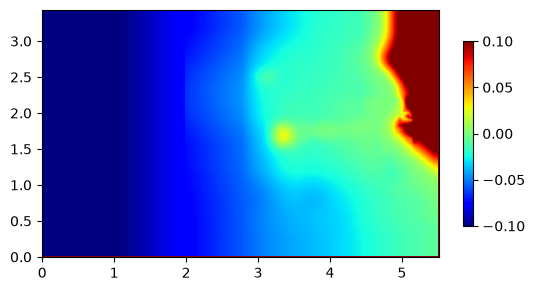

In [32]:
plt.pcolormesh(ds["x"],ds["y"],ds["z"], cmap="jet")
plt.clim([-0.1,0.1])
cbar = plt.colorbar(shrink=0.5)
plt.gca().set_aspect('equal', adjustable='box')

In [13]:
tide_data = np.loadtxt("MonaiValley_WaveGages_30s_02s.txt",skiprows=1)

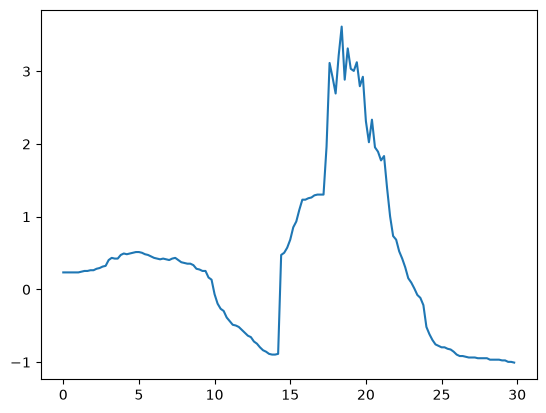

In [34]:
plt.plot(tide_data[:,0],tide_data[:,1])

## View checkpoint data

--- Checkpoint Contents ---
Saved at Epoch: 209
Best Loss achieved: 0.0000073777


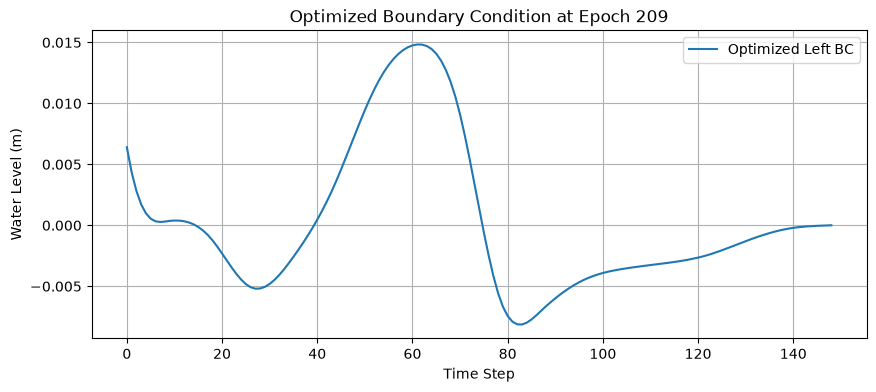

In [2]:
import torch

# 1. Load the checkpoint using PyTorch
# We use map_location='cpu' so you can inspect this on any machine, even without a GPU
checkpoint = torch.load("./inverse_results_spline/best_inverse_checkpoint.pth", map_location="cpu", weights_only=True)

# 2. See what is inside
print("--- Checkpoint Contents ---")
print(f"Saved at Epoch: {checkpoint['epoch']}")
print(f"Best Loss achieved: {checkpoint['train_loss']:.10f}")

# 3. Extract your optimized boundary condition parameter
# It is saved as a PyTorch tensor, so we convert it to a standard Numpy array to read it easily
bc_array = checkpoint['boundary_series'].numpy()

# 4. Optional: Plot the waveform!
plt.figure(figsize=(10, 4))
plt.plot(bc_array, label="Optimized Left BC")
plt.title(f"Optimized Boundary Condition at Epoch {checkpoint['epoch']}")
plt.xlabel("Time Step")
plt.ylabel("Water Level (m)")
plt.grid(True)
plt.legend()
plt.show()

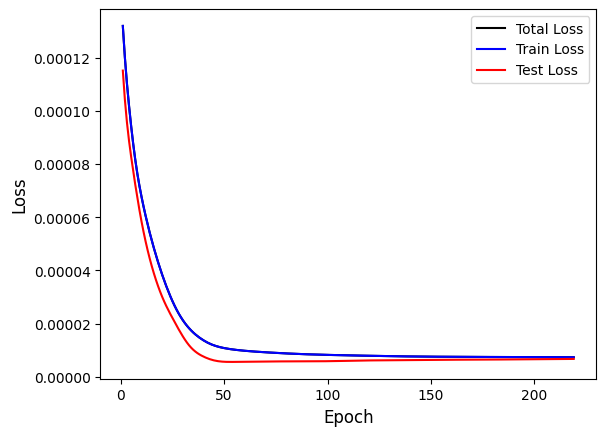

In [5]:
loss = np.loadtxt('./inverse_results_spline/loss_history.txt',skiprows=1)
plt.plot(loss[:,0],loss[:,1],label='Total Loss',color='k')
plt.plot(loss[:,0],loss[:,2],label='Train Loss',color='b')
plt.plot(loss[:,0],loss[:,3],label='Test Loss',color='r')
plt.xlabel('Epoch',fontsize=12)
plt.ylabel('Loss',fontsize=12)
plt.legend()
plt.savefig('./fig/loss_history_a.png', bbox_inches='tight', pad_inches=0.1, dpi=300)

In [7]:
gauge_data = np.loadtxt("./inverse_results_spline/best_gauge_comparison.txt",skiprows=1)

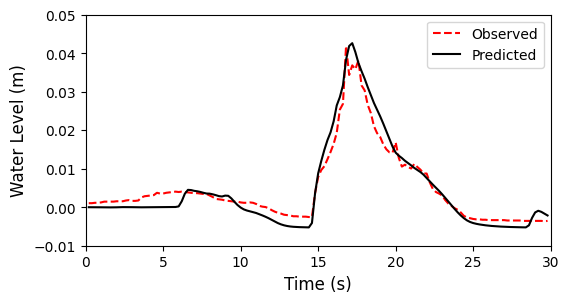

In [ ]:
plt.figure(figsize=(6, 3))
#plt.plot(gauge_data[:,0],gauge_data[:,1],gauge_data[:,0],gauge_data[:,2])
#plt.plot(gauge_data[:,0],gauge_data[:,3],gauge_data[:,0],gauge_data[:,4])
# plt.plot(gauge_data[:,0],gauge_data[:,5],gauge_data[:,0],gauge_data[:,6]) # test gauge
plt.plot(gauge_data[:,0],gauge_data[:,6],label='Observed',color='r',linestyle='dashed')
plt.plot(gauge_data[:,0],gauge_data[:,5],label='Predicted',color='k')
plt.xlabel('Time (s)',fontsize=12)
plt.ylabel('Water Level (m)',fontsize=12)
plt.xlim([0,30])
plt.ylim([-0.01,0.05])
plt.legend()
plt.savefig('./fig/inverse_bc_test_plot.png', bbox_inches='tight', pad_inches=0.1, dpi=300)

# Compare with input wave

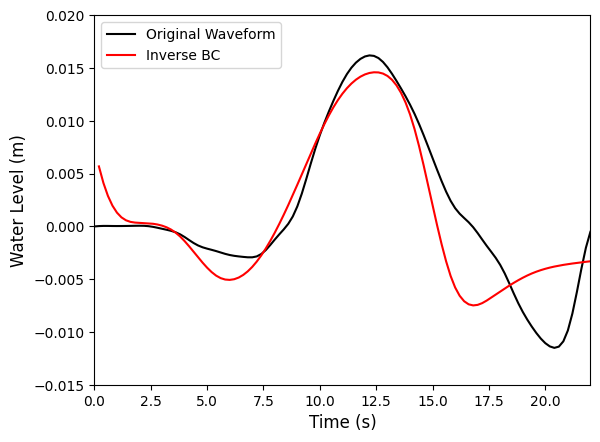

In [6]:
wl = np.load('./inverse_results_spline/boundary_evolution_history.npy')
time = np.arange(0.2, 29.8 + 0.2, 0.2)
input_wave = np.loadtxt('../input_wave_002s.txt')
# Plot
plt.plot(input_wave[:,0],input_wave[:,1],label='Original Waveform', color='k')
plt.plot(time,wl[153,:],label='Inverse BC',color='r')
plt.xlabel('Time (s)',fontsize=12)
plt.ylabel('Water Level (m)',fontsize=12)
plt.legend(loc ='upper left')
plt.xlim([0,22])
plt.ylim([-0.015,0.02])
plt.savefig('./fig/inverse_bc_plot.png', bbox_inches='tight', pad_inches=0.1, dpi=300)